In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()
titanic.describe()
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
features = ["pclass", "sex", "fare", "age", "embarked"]
target = ["survived"]

In [6]:
# missing values
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic["age"] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic["embarked"] = imp_freq.fit_transform(titanic[["embarked"]]).ravel()# we use ravel to convert the 2D array to 1D

In [7]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
# Encoding 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [9]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [10]:
X = titanic[features]
y = titanic[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
#load the model no pruning

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)


DecisionTreeClassifier()

In [12]:
y_pred = model.predict(X_test)

In [13]:
#evaluate the perfromance of the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))    
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7653631284916201
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79       105
           1       0.70      0.76      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179

Confusion Matrix:
 [[81 24]
 [18 56]]


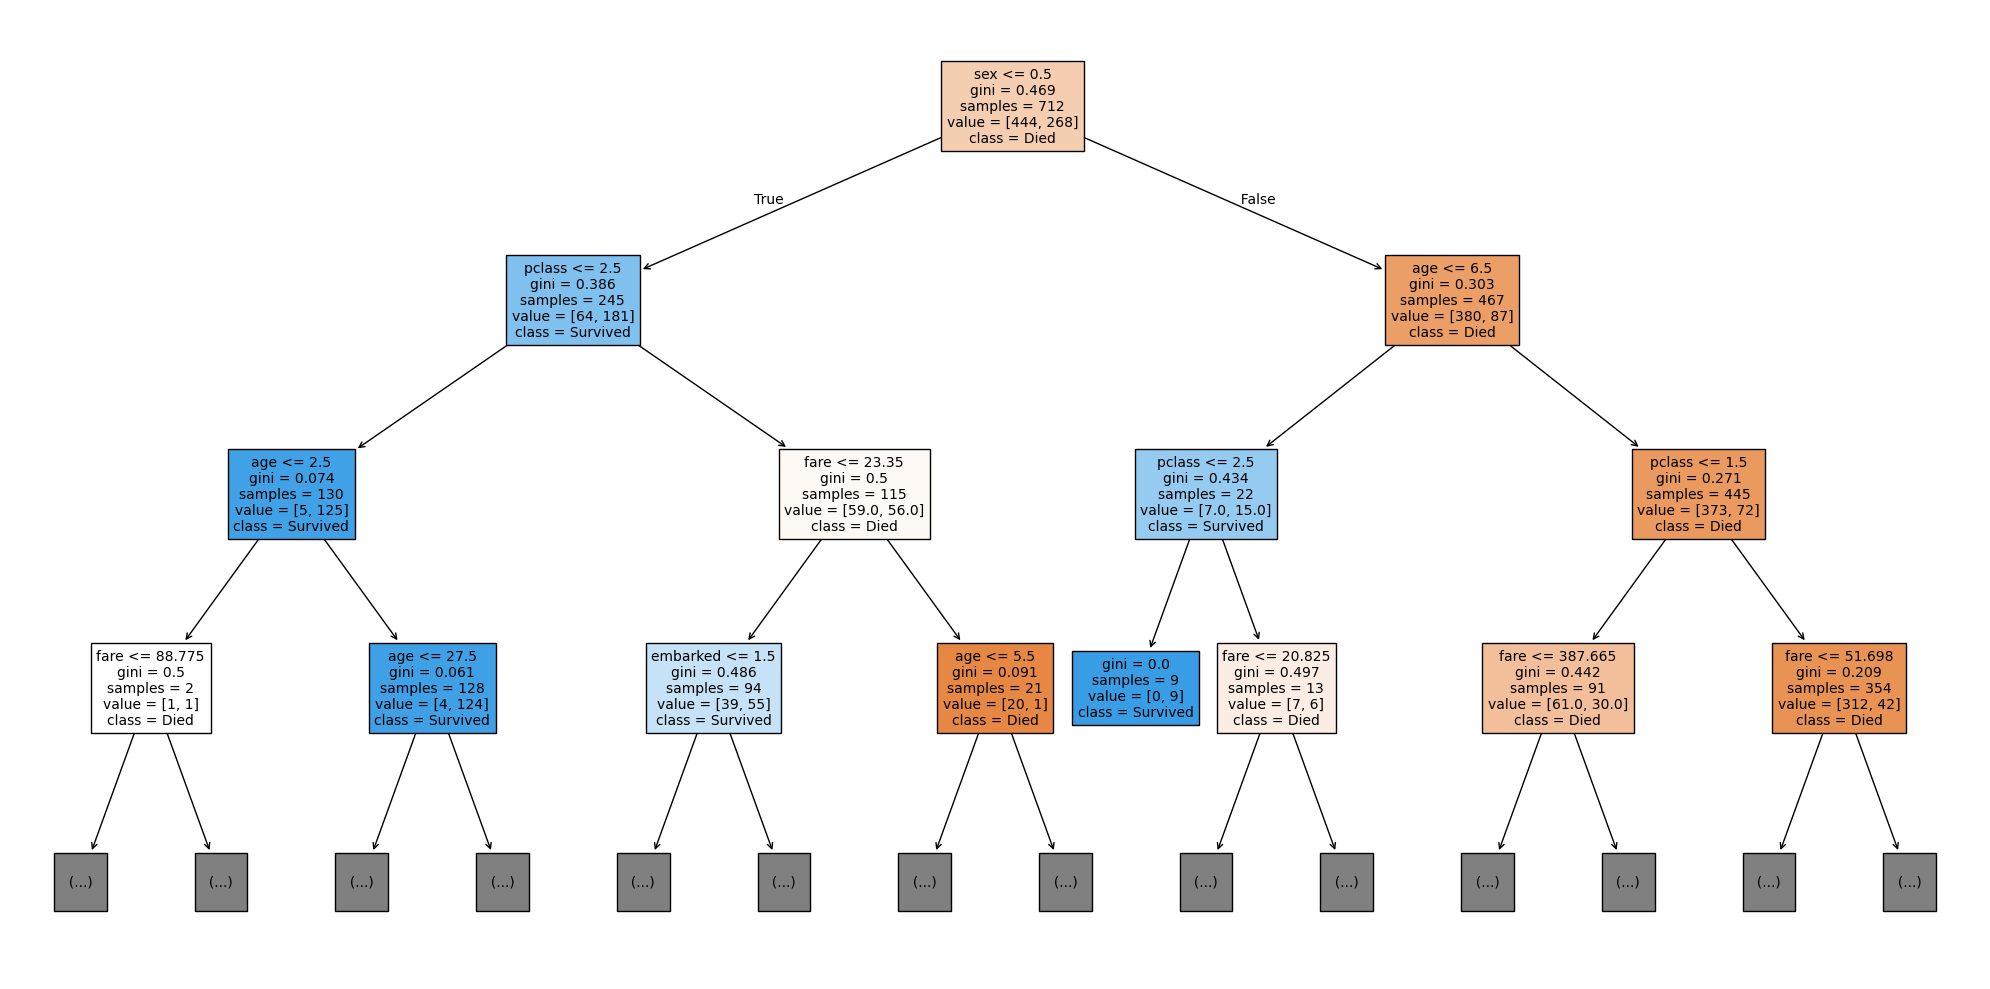

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=features, 
    class_names=["Died", "Survived"], #targets 
    filled=True,
    max_depth=3, # limit the depth of the tree for better visualization
    fontsize=10)

plt.tight_layout()
plt.show()

# Decesion Tree with pre-Pruning

Max Depth: 2, Accuracy: 0.7654
Max Depth: 3, Accuracy: 0.7989
Max Depth: 4, Accuracy: 0.7989


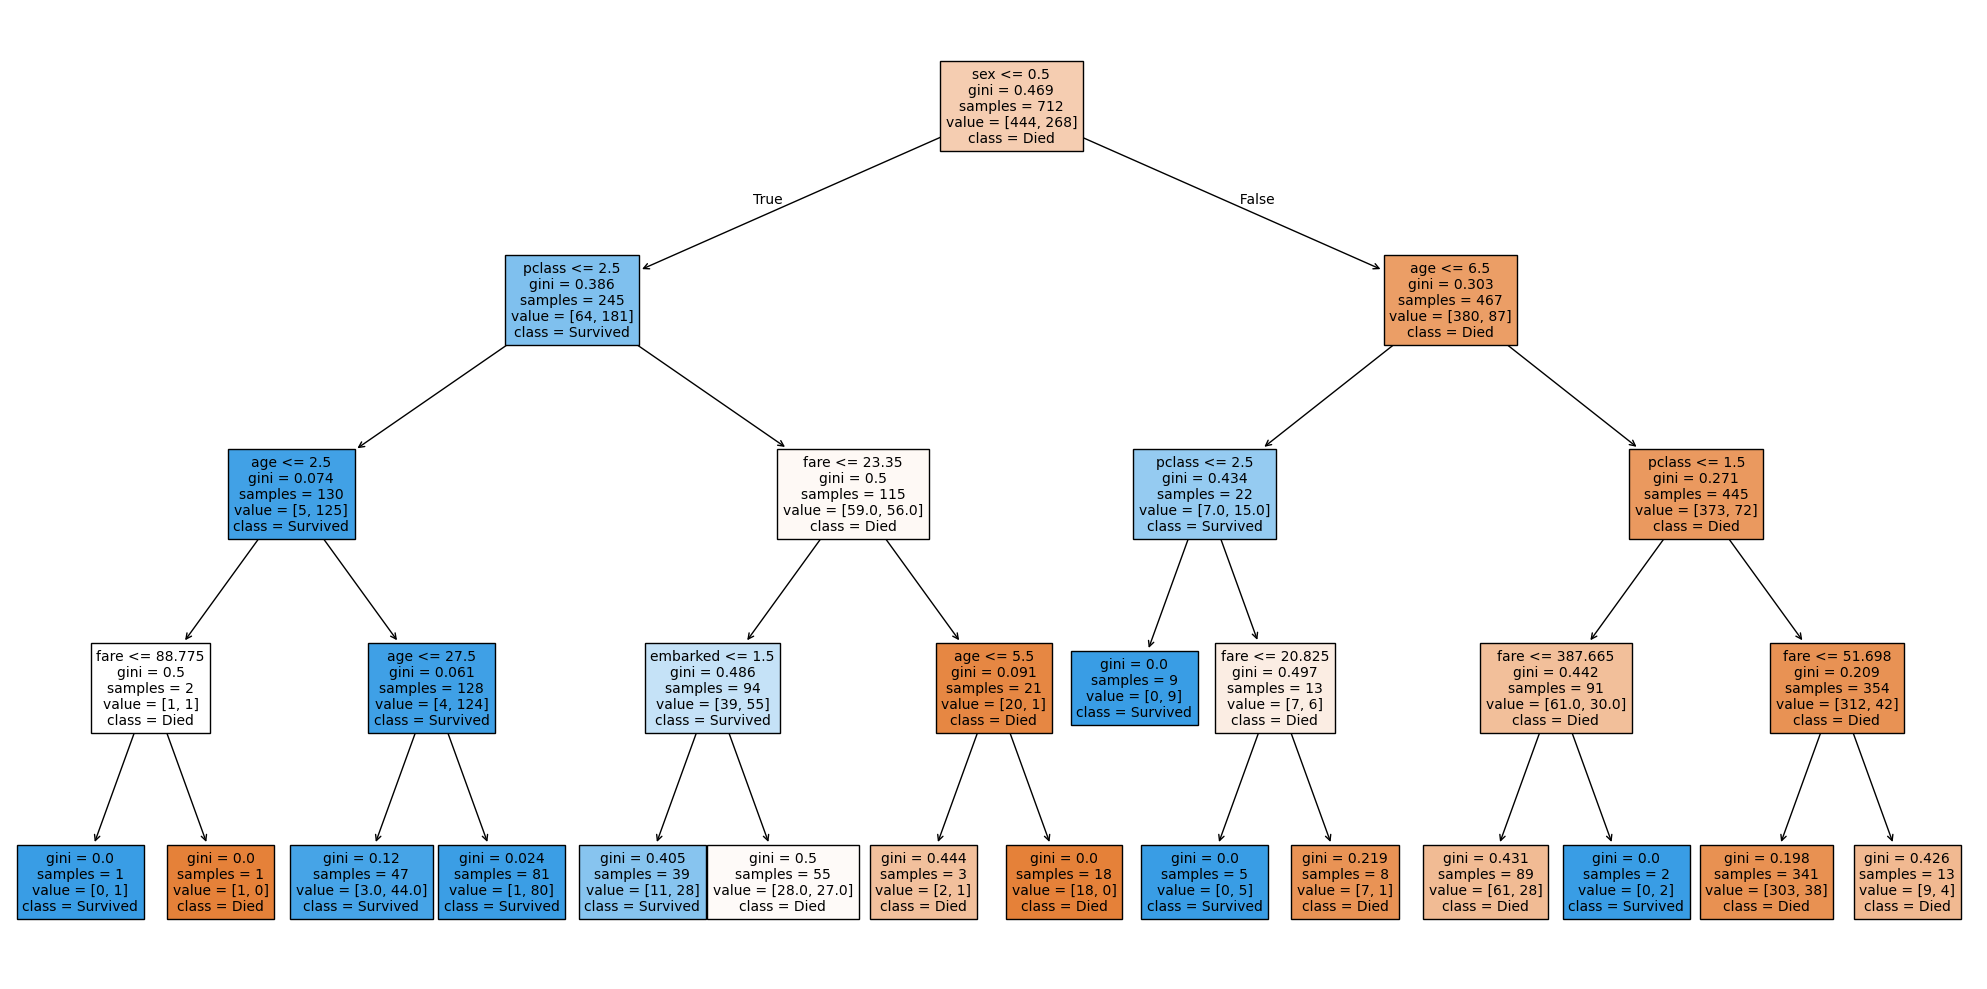

Max Depth: 5, Accuracy: 0.7989
Max Depth: 6, Accuracy: 0.7989
Max Depth: 7, Accuracy: 0.7933
Max Depth: 8, Accuracy: 0.7877
Max Depth: 9, Accuracy: 0.8045
Max Depth: 10, Accuracy: 0.7877


In [15]:
max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10] # we will test different max_depth values to see how it affects the accuracy of the model
for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    
    acc= model.score(X_test, y_test)
    print(f"Max Depth: {depth}, Accuracy: {acc:.4f}")
    
    if(depth == 4):
        plt.figure(figsize=(20,10))
        plot_tree(
            model,
            feature_names=features, 
            class_names=["Died", "Survived"], #targets 
            filled=True,
            # limit the depth of the tree for better visualization
            fontsize=10)

        plt.tight_layout()
        plt.show()
    


Min Samples Split: 10, Accuracy: 0.7988826815642458


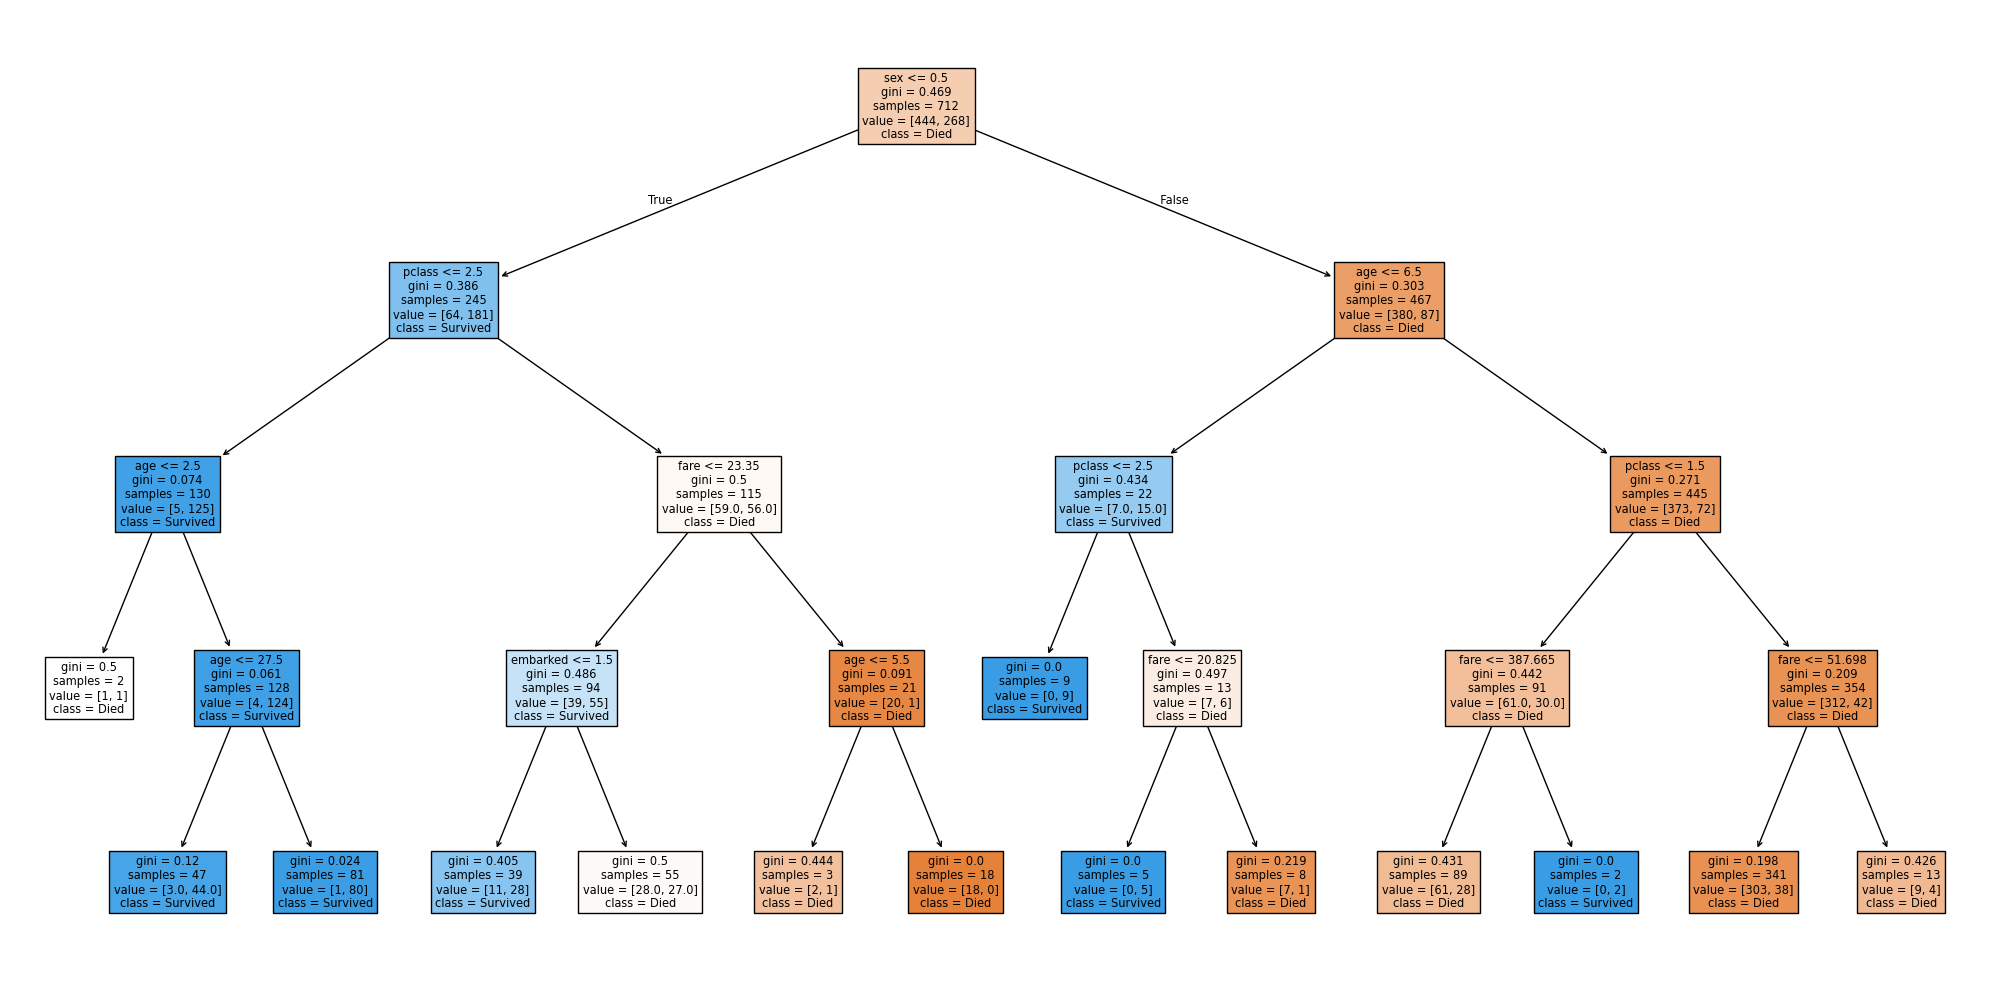

Min Samples Split: 15, Accuracy: 0.7988826815642458
Min Samples Split: 20, Accuracy: 0.7988826815642458
Min Samples Split: 25, Accuracy: 0.7932960893854749
Min Samples Split: 30, Accuracy: 0.7932960893854749
Min Samples Split: 35, Accuracy: 0.7932960893854749
Min Samples Split: 40, Accuracy: 0.7932960893854749
Min Samples Split: 45, Accuracy: 0.7932960893854749
Min Samples Split: 50, Accuracy: 0.7932960893854749


In [16]:
min_samples_split = [10,15, 20,25, 30, 35, 40, 45, 50]
for split in min_samples_split:
    model = DecisionTreeClassifier( max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)
    print(f"Min Samples Split: {split}, Accuracy: {acc}")
    
    if(split == 10):
        plt.figure(figsize = (20,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True,
        )
        plt.tight_layout()
        plt.show()

    
    

# Decison tree with post_pruning

In [17]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
path =full_tree.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas

print(f"CCP Alphas: {ccp_alphas}")


CCP Alphas: [0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e

In [19]:
# train the model with different ccp_alpha values and evaluate the accuracy
tree =[]

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)
    tree.append((model, alpha))
    

In [21]:
best_acc = 0
best_alpha = 0

for model, alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if curr_acc  > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [22]:
print(best_alpha)
print(best_acc)

0.0015407231242023183
0.8379888268156425


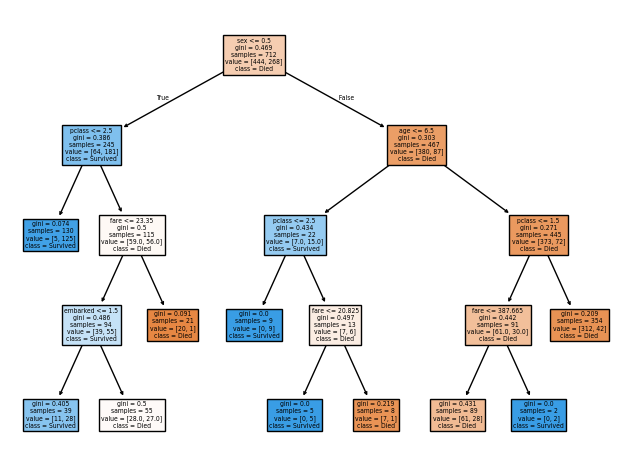

In [25]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha,max_depth = 4)
best_model.fit(X_train, y_train)

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names= ["Died" , "Survived"],
    filled = True   
)
plt.tight_layout()
plt.show()

In [ ]:
print(best_model.score(X_test, y_test))

0.7988826815642458


In [ ]:
print(best_model.score(X_test, y_test))